# 1. Data Preparation

## (a) Data cleansing and transformation

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# Calculating dataset mean and std

tf = transforms.Compose([transforms.ToTensor()])

initial_dataset = datasets.STL10(root='./data', split='train', download=True, transform=tf)
initial_loader = DataLoader(initial_dataset, batch_size=128, shuffle=False, num_workers=2)

mean = 0.0
sq_mean = 0.0

for imgs, labels in initial_loader:
  b, c, h, w = imgs.shape
  flatten = imgs.view(b, c, -1)
  mean += flatten.mean(2).sum(0)
  sq_mean += (flatten**2).mean(2).sum(0)

mean /= 5000
std = (sq_mean/5000 - mean**2)**0.5

print(f"Mean: {mean}")
print(f"Std: {std}")

100%|██████████| 2.64G/2.64G [03:15<00:00, 13.5MB/s]


Mean: tensor([0.4467, 0.4398, 0.4066])
Std: tensor([0.2603, 0.2566, 0.2713])


In [ ]:
# Data transformation (stl-10 is already clean)

train_tf = transforms.Compose([
  transforms.RandomResizedCrop(96, scale=(0.5, 1.0)), # random crop with 50% to 100% scale
  transforms.RandomHorizontalFlip(p=0.5), # random 50/50 horizontal flip
  transforms.RandAugment(num_ops=2, magnitude=5), # does 2 random pytorch augments with strength 5/10 (*)
  transforms.ToTensor(), # converts to a tensor (necessary)
  transforms.Normalize(mean.tolist(), std.tolist()), # normalizes using the mean and std I calculated above
  transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), value='random') # erases 2% to 20% of the image 20% of the time
])

eval_tf = transforms.Compose([ # only doing the necessary augmentations for evaluation mode
  transforms.ToTensor(),
  transforms.Normalize(mean.tolist(), std.tolist())
])

train_set = datasets.STL10(root='./data', split='train', download=True, transform=train_tf)
test_set = datasets.STL10(root='./data', split='test', download=True, transform=eval_tf)

## (b) Data splitting

In [ ]:
from torch.utils.data import random_split

In [ ]:
# Splitting to get val set

train_size = int(0.8 * len(train_set))
val_size = len(train_set) - train_size
train_set, val_set = random_split(train_set, [train_size, val_size])
val_set.dataset.transform = eval_tf

In [ ]:
# Pytorch dataloaders

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

# 2. Exploratory Data Analysis (EDA)

## (a) Descriptive statistics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataset sizes

print(f"Train set size: {len(train_set)}")
print(f"Val set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

Train set size: 4000
Val set size: 1000
Test set size: 8000


In [ ]:
# Class distributions

classes = np.array(['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck'])

train_labels = np.array(train_set.dataset.labels)[train_set.indices]
train_counts = np.bincount(train_labels)

val_labels = np.array(val_set.dataset.labels)[val_set.indices]
val_counts = np.bincount(val_labels)

test_labels = np.array(test_set.labels)
test_counts = np.bincount(test_labels)

for name, counts in zip(['Train', 'Val', 'Test'], [train_counts, val_counts, test_counts]):
  print(f"{name} class distribution:")
  for cls, count in zip(classes, counts):
    print(f"   {cls}: {count}")
  print()

Train class distribution:
   airplane: 401
   bird: 411
   car: 388
   cat: 413
   deer: 407
   dog: 404
   horse: 383
   monkey: 401
   ship: 392
   truck: 400

Val class distribution:
   airplane: 99
   bird: 89
   car: 112
   cat: 87
   deer: 93
   dog: 96
   horse: 117
   monkey: 99
   ship: 108
   truck: 100

Test class distribution:
   airplane: 800
   bird: 800
   car: 800
   cat: 800
   deer: 800
   dog: 800
   horse: 800
   monkey: 800
   ship: 800
   truck: 800



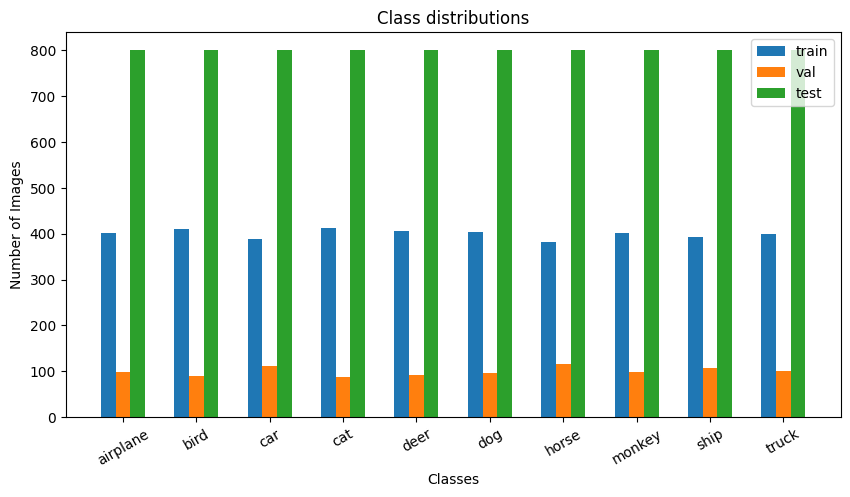

In [ ]:
# Barplot

x = np.arange(10)
plt.figure(figsize=(10,5))
plt.bar(x-0.2, train_counts, width=0.2, label='train')
plt.bar(x, val_counts, width=0.2, label='val')
plt.bar(x+0.2, test_counts, width=0.2, label='test')
plt.xticks(x, classes, rotation=30)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class distributions")
plt.legend()
plt.show()

## (b) Data visualization

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

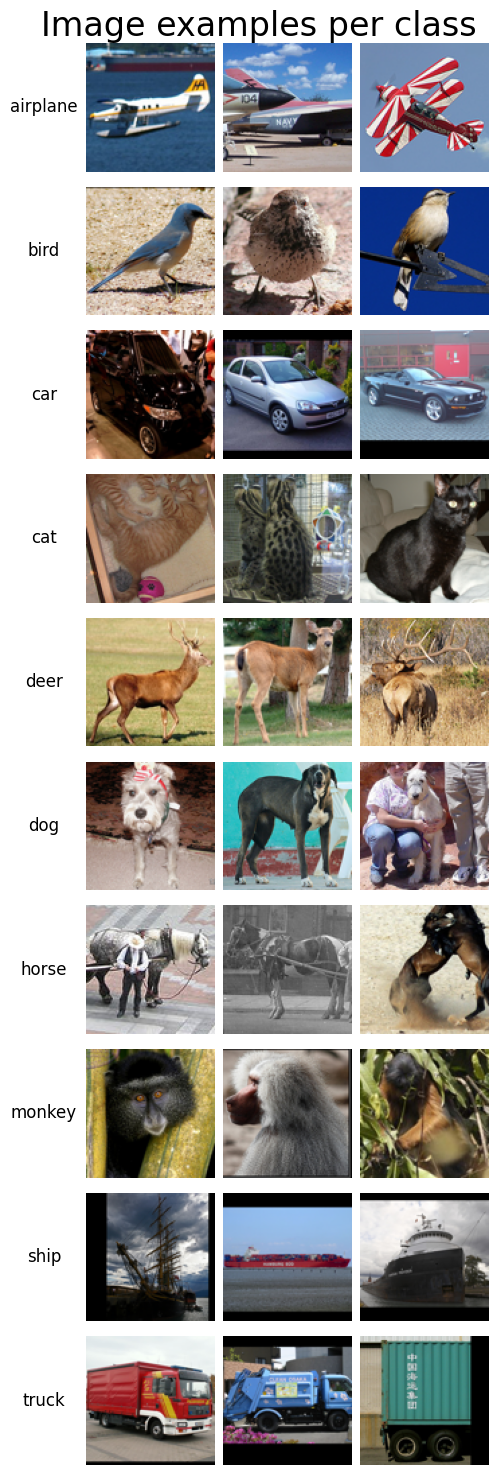

In [ ]:
# Image examples from classes

inverse_normalize = transforms.Normalize((-mean/std).tolist(), (1.0/std).tolist())

num_imgs = 3
imgs = []
for cls in range(10):
  count = 0
  for index in train_set.indices:
    img, label = train_set.dataset[index]
    if label == cls:
      imgs.append((cls, inverse_normalize(img)))
      count += 1
    if count >= num_imgs:
      break

plt.figure(figsize=(5, 15))

for i in range(10):
  for j in range(num_imgs):
    cls, img = imgs[i*num_imgs + j] # img.shape = c, h, w
    img_tr = np.transpose(img, (1,2,0)) # img_tr.shape = h, w, c
    img_clip = np.clip(img_tr, 0, 1)
    plt.subplot(10, num_imgs, i*num_imgs + j + 1) # nrows, ncols, index
    plt.imshow(img_clip)
    plt.axis('off')
    if j == 0:
      plt.text(-0.33, 0.5, classes[cls], fontsize=12, rotation=0, va='center', ha='center', transform=plt.gca().transAxes)

plt.suptitle("Image examples per class", fontsize=24)
plt.tight_layout()
plt.show()


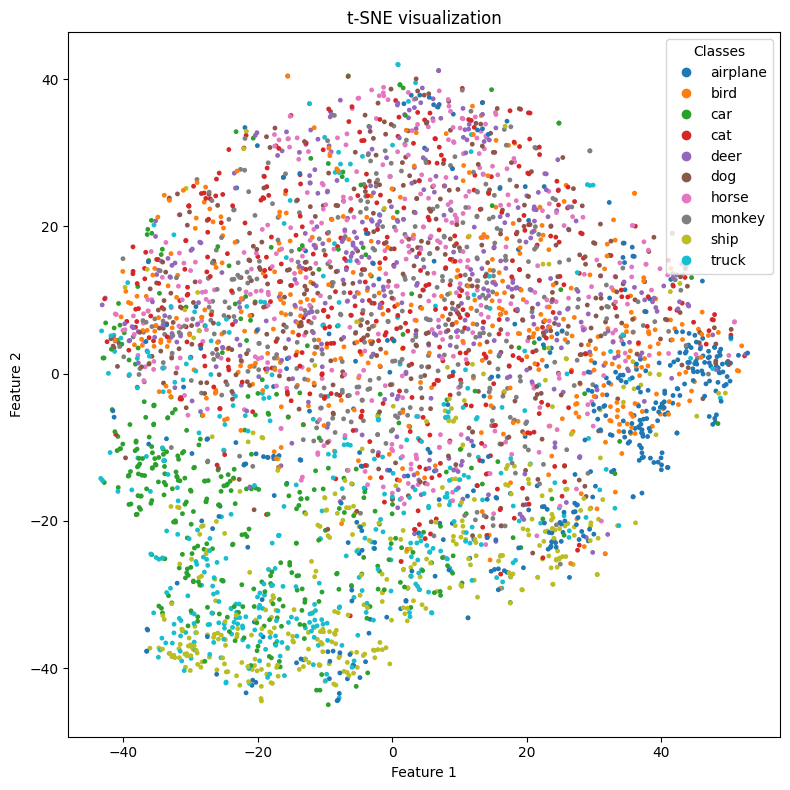

In [ ]:
# Dimensionality reduction visualization
# Works better than I expected, you can actually see how the vehicles and animals are separated

imgs = []
labels = []
for index in train_set.indices:
  img, label = train_set.dataset[index]
  imgs.append(img.view(-1)) # images flattened
  labels.append(label)

raw_dataset = torch.stack(imgs).numpy() # (n_samples, n_features)
labels = np.array(labels)

pca = PCA(n_components = 100) # 27,648 -> 100 features because tsne is very slow
pca_dataset = pca.fit_transform(raw_dataset)
tsne = TSNE(n_components = 2)
tsne_dataset = tsne.fit_transform(pca_dataset)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(tsne_dataset[:,0], tsne_dataset[:,1], s=6, c=labels, cmap='tab10')
plt.title('t-SNE visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=list(classes), title="Classes", loc='upper right')

plt.tight_layout()
plt.show()


# 3. Model Selection

## (a) Justification

Neural netowrks are the obvious choice for image classification because they are great at modeling highly non-linear relationships in extremely high-dimensional data, which is what you see in images. Compared to other algorithms like KNN or decision trees, neural networks can achieve much greater performance on this type of complex data without extensive feature engineering.

We are using a convolutional neural network (CNN) in particular because of the structure of images. Images have a ton of parameters because each pixel is a separate datapoint, and each image has 96x96 pixels in this case. Traditional neural networks treat each of these as an independent feature and use fully connected layers. This is an issue because fully connected layers are massive on this many datapoints, and pixels in an image are not independent, they are correlated to nearby pixels.

CNNs solve both of these problems by using convolutional filters and pooling layers, which take the similarity of nearby pixels into account, and drastically reduce the number of parameters in a model. Because of this, CNNs are the standard for image classification.

## (b) Model building

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy

In [ ]:
# Models

# CNN I made
class CNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.backbone = nn.Sequential(
      # start at 96x96

      nn.Conv2d(3, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2), # 48x48

      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(),
      nn.MaxPool2d(2), # 24x24

      nn.Conv2d(128, 256, kernel_size=3, padding=1),
      nn.BatchNorm2d(256),
      nn.ReLU(),
      nn.MaxPool2d(2), # 12x12

      nn.Conv2d(256, 512, kernel_size=3, padding=1),
      nn.BatchNorm2d(512),
      nn.ReLU(),
      nn.MaxPool2d(2), # 6x6

      nn.Conv2d(512, 1024, kernel_size=3, padding=1),
      nn.BatchNorm2d(1024),
      nn.ReLU(),
      nn.MaxPool2d(2), # 6x6
    )

    self.head = nn.Sequential(
      nn.AdaptiveAvgPool2d(1), # 1x1
      nn.Flatten(),
      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.Linear(512, num_classes) # output logits
    )

  def forward(self, x):
    x = self.backbone(x)
    x = self.head(x)
    return x


# Premade resnet18
class Imported_resnet18(nn.Module):
    def __init__(self, num_classes=10, pretrain=True):
        super().__init__()
        if pretrain:
          weights = "IMAGENET1K_V1"
        else:
          weights = None
        self.model = resnet18(weights=weights)

        # Modify the detector to predict 10 classes
        detector_features = self.model.fc.in_features
        self.model.fc = nn.Linear(detector_features, num_classes)

    def forward(self, x):
        return self.model(x)


In [ ]:
# Training and evaluation functions

def train_loop(model, loader, optimizer, criterion):
  model.train()
  device = "cuda"
  total_loss = 0.0
  correct_count = 0
  img_count = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * images.shape[0]
    max_logits, indices = outputs.max(1)
    correct_count += (indices == labels).sum().item()
    img_count += labels.shape[0]

  loss = total_loss / img_count
  accuracy = correct_count / img_count
  return loss, accuracy

def evaluate(model, loader, criterion):
  model.eval()
  device = "cuda"
  total_loss = 0.0
  correct_count = 0
  img_count = 0

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.shape[0]
      max_logits, indices = outputs.max(1)
      correct_count += (indices == labels).sum().item()
      img_count += labels.shape[0]

  loss = total_loss / img_count
  accuracy = correct_count / img_count
  return loss, accuracy

In [ ]:
# Hyperparameter tuning small CNN model
# About 70% accuracy on val/test is as good as I can get with a basic CNN. I could do better with a resnet, but it's more complicated.
# Just by the nature of how CNNs work, it's going to overfit. This is fine, I have prevented overfitting as well as can be done.
# To further prevent overfitting, the model would have to be nerfed too hard which would hurt test accuracy, and test accuracy is the entire point.

hyperparameters = [
  {"lr": 1e-4,  "weight_decay": 1e-4},
  {"lr": 1e-4,  "weight_decay": 1e-3},
  {"lr": 1e-3,  "weight_decay": 1e-4},
  {"lr": 1e-3,  "weight_decay": 1e-3},
  {"lr": 1e-4,  "weight_decay": 1e-4},
  {"lr": 1e-4,  "weight_decay": 1e-3},
  {"lr": 1e-3,  "weight_decay": 1e-4},
  {"lr": 1e-3,  "weight_decay": 1e-3},
]

epochs = 50
best_val_accuracy = 0.0
best_hp = None
CNN_model = None
device = "cuda"

for hp in hyperparameters:
  print(f"\nHyperparameters: {hp}\n")

  model = CNN().to(device)
  criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer = optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
  scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

  for epoch in range(1, epochs + 1):
    train_loss, train_accuracy = train_loop(model, train_loader, optimizer, criterion)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02}: Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy*100:.2f}%, Val loss: {val_loss:.4f}, Val accuracy: {val_accuracy*100:.2f}%")

    if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      best_hp = hp
      CNN_model = copy.deepcopy(model.state_dict())

print("\nBest hyperparameters:", best_hp)
print(f"Best val accuracy: {best_val_accuracy*100:.2f}%")



Hyperparameters: {'lr': 0.0001, 'weight_decay': 0.0001}

Epoch 01: Train loss: 1.8460, Train accuracy: 35.80%, Val loss: 1.9303, Val accuracy: 32.60%
Epoch 02: Train loss: 1.5532, Train accuracy: 51.55%, Val loss: 1.6429, Val accuracy: 46.10%
Epoch 03: Train loss: 1.4208, Train accuracy: 57.67%, Val loss: 1.4886, Val accuracy: 54.70%
Epoch 04: Train loss: 1.3011, Train accuracy: 64.78%, Val loss: 1.4464, Val accuracy: 59.70%
Epoch 05: Train loss: 1.2138, Train accuracy: 69.15%, Val loss: 1.5816, Val accuracy: 51.70%
Epoch 06: Train loss: 1.1398, Train accuracy: 73.83%, Val loss: 1.3634, Val accuracy: 61.70%
Epoch 07: Train loss: 1.0347, Train accuracy: 79.20%, Val loss: 1.3533, Val accuracy: 62.50%
Epoch 08: Train loss: 0.9640, Train accuracy: 83.47%, Val loss: 1.6133, Val accuracy: 53.10%
Epoch 09: Train loss: 0.8755, Train accuracy: 88.02%, Val loss: 1.4260, Val accuracy: 57.70%
Epoch 10: Train loss: 0.8008, Train accuracy: 92.05%, Val loss: 1.6462, Val accuracy: 50.60%
Epoch 11: Tr

In [ ]:
# Hyperparameter tuning resnet18

hyperparameters = [
  {"pretrain": False, "lr": 1e-4,  "weight_decay": 1e-4},
  {"pretrain": True, "lr": 1e-4,  "weight_decay": 1e-4},
  {"pretrain": True, "lr": 1e-4,  "weight_decay": 1e-3},
  {"pretrain": True, "lr": 1e-3,  "weight_decay": 1e-4},
  {"pretrain": True, "lr": 1e-3,  "weight_decay": 1e-3},
  {"pretrain": True, "lr": 1e-4,  "weight_decay": 1e-4},
  {"pretrain": True, "lr": 1e-4,  "weight_decay": 1e-3},
  {"pretrain": True, "lr": 1e-3,  "weight_decay": 1e-4},
  {"pretrain": True, "lr": 1e-3,  "weight_decay": 1e-3},
]

epochs = 20
best_val_accuracy = 0.0
best_res_hp = None
resnet_model = None
device = "cuda"

for hp in hyperparameters:
  print(f"\nHyperparameters: {hp}\n")

  model = Imported_resnet18(pretrain=hp["pretrain"]).to(device)
  criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer = optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
  scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

  for epoch in range(1, epochs + 1):
    train_loss, train_accuracy = train_loop(model, train_loader, optimizer, criterion)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02}: Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy*100:.2f}%, Val loss: {val_loss:.4f}, Val accuracy: {val_accuracy*100:.2f}%")

    if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      best_res_hp = hp
      resnet_model = copy.deepcopy(model.state_dict())

print("\nBest hyperparameters:", best_res_hp)
print(f"Best val accuracy: {best_val_accuracy*100:.2f}%")



Hyperparameters: {'pretrain': False, 'lr': 0.0001, 'weight_decay': 0.0001}

Epoch 01: Train loss: 2.0180, Train accuracy: 27.75%, Val loss: 1.9555, Val accuracy: 27.10%
Epoch 02: Train loss: 1.4946, Train accuracy: 60.70%, Val loss: 1.6571, Val accuracy: 47.40%
Epoch 03: Train loss: 1.0540, Train accuracy: 85.05%, Val loss: 1.7100, Val accuracy: 44.10%
Epoch 04: Train loss: 0.6659, Train accuracy: 98.52%, Val loss: 1.7277, Val accuracy: 45.20%
Epoch 05: Train loss: 0.5567, Train accuracy: 99.92%, Val loss: 1.7814, Val accuracy: 43.10%
Epoch 06: Train loss: 0.5361, Train accuracy: 100.00%, Val loss: 1.7739, Val accuracy: 44.00%
Epoch 07: Train loss: 0.5264, Train accuracy: 100.00%, Val loss: 1.7679, Val accuracy: 43.90%
Epoch 08: Train loss: 0.5221, Train accuracy: 100.00%, Val loss: 1.7744, Val accuracy: 43.30%
Epoch 09: Train loss: 0.5185, Train accuracy: 100.00%, Val loss: 1.7896, Val accuracy: 41.90%
Epoch 10: Train loss: 0.5175, Train accuracy: 100.00%, Val loss: 1.7842, Val accur

100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


Epoch 01: Train loss: 1.3128, Train accuracy: 67.00%, Val loss: 0.8816, Val accuracy: 85.00%
Epoch 02: Train loss: 0.6981, Train accuracy: 95.25%, Val loss: 0.8332, Val accuracy: 87.50%
Epoch 03: Train loss: 0.5741, Train accuracy: 99.75%, Val loss: 0.8130, Val accuracy: 89.10%
Epoch 04: Train loss: 0.5392, Train accuracy: 99.98%, Val loss: 0.8159, Val accuracy: 88.40%
Epoch 05: Train loss: 0.5280, Train accuracy: 100.00%, Val loss: 0.8113, Val accuracy: 88.80%
Epoch 06: Train loss: 0.5223, Train accuracy: 100.00%, Val loss: 0.8054, Val accuracy: 88.70%
Epoch 07: Train loss: 0.5190, Train accuracy: 100.00%, Val loss: 0.8123, Val accuracy: 89.00%
Epoch 08: Train loss: 0.5170, Train accuracy: 100.00%, Val loss: 0.8097, Val accuracy: 88.80%
Epoch 09: Train loss: 0.5156, Train accuracy: 100.00%, Val loss: 0.8143, Val accuracy: 89.00%
Epoch 10: Train loss: 0.5147, Train accuracy: 100.00%, Val loss: 0.8077, Val accuracy: 89.00%
Epoch 11: Train loss: 0.5149, Train accuracy: 100.00%, Val loss:

## (c) Model evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
# Evaluate on test set

num_runs = 5
cnn_epochs = 50
resnet_epochs = 20

def test_with_outputs(model, loader, criterion):
  model.eval()
  device = "cuda"
  total_loss = 0.0
  all_preds = []
  all_labels = []
  img_count = 0

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * labels.shape[0]
      img_count += labels.shape[0]

      max_logits, indices = outputs.max(1)
      all_preds.extend(indices.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  all_preds = np.array(all_preds)
  all_labels = np.array(all_labels)
  avg_loss = total_loss / img_count
  accuracy = (all_preds == all_labels).mean()
  return avg_loss, accuracy, all_labels, all_preds

def run_experiments(model_class, lr, weight_decay, epochs, model_name, extra_kwargs=None):
  if extra_kwargs is None:
    extra_kwargs = {}

  test_losses = []
  test_accuracies = []
  reports = []
  conf_mats = []

  for run in range(1, num_runs + 1):
    print(f"\n{model_name} run {run}/{num_runs}")
    model = model_class(**extra_kwargs).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(1, epochs + 1):
      train_loss, train_accuracy = train_loop(model, train_loader, optimizer, criterion)
      val_loss, val_accuracy = evaluate(model, val_loader, criterion)
      scheduler.step()

      print(f"Epoch {epoch:02}: Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy*100:.2f}%, Val loss: {val_loss:.4f}, Val accuracy: {val_accuracy*100:.2f}%")

    test_loss, test_accuracy, y_true, y_pred = test_with_outputs(model, test_loader, criterion)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    cm = confusion_matrix(y_true, y_pred)
    conf_mats.append(cm)

    rep = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    reports.append(rep)

    print(f"Test accuracy run {run}: {test_accuracy*100:.2f}%")

  results = {
    "test_losses": np.array(test_losses),
    "test_accuracies": np.array(test_accuracies),
    "reports": reports,
    "conf_mats": conf_mats,
  }

  print(f"\n{model_name} mean test accuracy over {num_runs} runs: {results['test_accuracies'].mean()*100:.2f}% +/- {results['test_accuracies'].std()*100:.2f}%")

  return results

# My basic CNN
cnn_results = run_experiments(
  CNN,
  best_hp["lr"],
  best_hp["weight_decay"],
  cnn_epochs,
  "Basic CNN"
)

# resnet18
resnet_results = run_experiments(
  Imported_resnet18,
  best_res_hp["lr"],
  best_res_hp["weight_decay"],
  resnet_epochs,
  "resnet18",
  extra_kwargs={"pretrain": True}
)


Basic CNN run 1/5
Epoch 01: Train loss: 1.9621, Train accuracy: 27.52%, Val loss: 1.8009, Val accuracy: 33.60%
Epoch 02: Train loss: 1.7320, Train accuracy: 38.42%, Val loss: 1.6557, Val accuracy: 45.20%
Epoch 03: Train loss: 1.6201, Train accuracy: 46.00%, Val loss: 1.7855, Val accuracy: 36.20%
Epoch 04: Train loss: 1.5684, Train accuracy: 49.05%, Val loss: 2.2120, Val accuracy: 29.00%
Epoch 05: Train loss: 1.4670, Train accuracy: 55.35%, Val loss: 1.6642, Val accuracy: 44.70%
Epoch 06: Train loss: 1.3864, Train accuracy: 59.05%, Val loss: 1.5966, Val accuracy: 49.20%
Epoch 07: Train loss: 1.3509, Train accuracy: 60.90%, Val loss: 1.5103, Val accuracy: 54.30%
Epoch 08: Train loss: 1.3097, Train accuracy: 63.05%, Val loss: 1.3865, Val accuracy: 59.50%
Epoch 09: Train loss: 1.2251, Train accuracy: 66.80%, Val loss: 1.7998, Val accuracy: 49.40%
Epoch 10: Train loss: 1.1786, Train accuracy: 70.12%, Val loss: 1.4819, Val accuracy: 54.40%
Epoch 11: Train loss: 1.1333, Train accuracy: 71.95

Basic CNN test performance over 5 runs: 
Test Accuracy: 76.28% ± 0.64%
Test Loss: 1.0855 ± 0.0097

Classification report (mean ± std over 5 runs):

Class               Precision          Recall           F1-score          Support        
-----------------------------------------------------------------------------------------
airplane         0.8747 ± 0.0076   0.8635 ± 0.0077   0.8690 ± 0.0051       800.0
bird             0.7401 ± 0.0138   0.7308 ± 0.0150   0.7353 ± 0.0134       800.0
car              0.9135 ± 0.0068   0.8705 ± 0.0132   0.8914 ± 0.0079       800.0
cat              0.6542 ± 0.0221   0.6685 ± 0.0158   0.6608 ± 0.0051       800.0
deer             0.7308 ± 0.0110   0.7137 ± 0.0141   0.7221 ± 0.0108       800.0
dog              0.5866 ± 0.0132   0.5755 ± 0.0168   0.5808 ± 0.0117       800.0
horse            0.7638 ± 0.0076   0.7730 ± 0.0153   0.7683 ± 0.0105       800.0
monkey           0.6905 ± 0.0051   0.7235 ± 0.0224   0.7064 ± 0.0096       800.0
ship             0.8566 

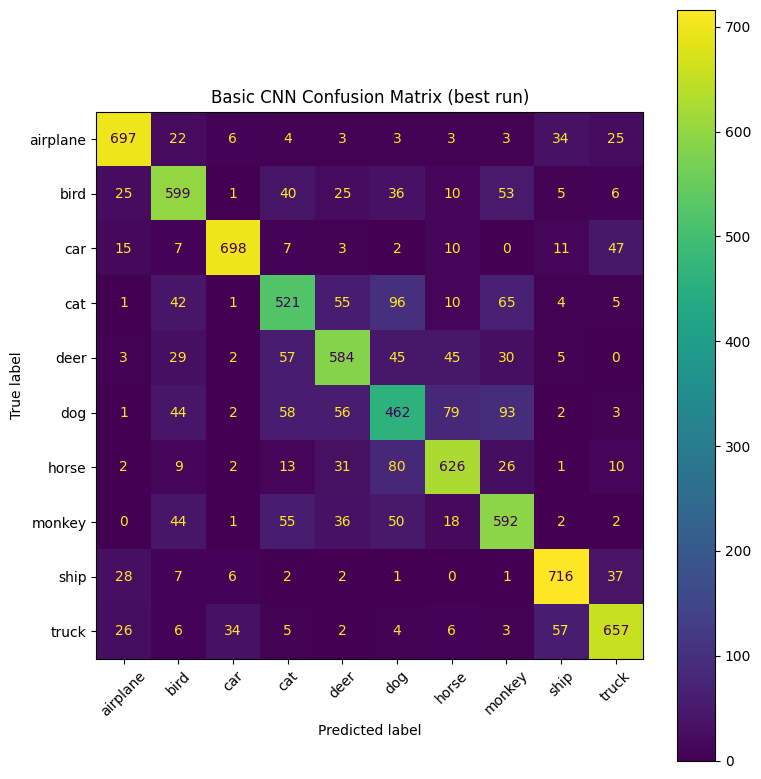

resnet18 test performance over 5 runs: 
Test Accuracy: 87.84% ± 0.31%
Test Loss: 0.8291 ± 0.0065

Classification report (mean ± std over 5 runs):

Class               Precision          Recall           F1-score          Support        
-----------------------------------------------------------------------------------------
airplane         0.9164 ± 0.0084   0.9192 ± 0.0042   0.9178 ± 0.0031       800.0
bird             0.9373 ± 0.0057   0.8965 ± 0.0065   0.9164 ± 0.0048       800.0
car              0.9382 ± 0.0065   0.9217 ± 0.0073   0.9299 ± 0.0028       800.0
cat              0.8225 ± 0.0211   0.7987 ± 0.0211   0.8100 ± 0.0070       800.0
deer             0.8499 ± 0.0143   0.8770 ± 0.0092   0.8631 ± 0.0082       800.0
dog              0.8061 ± 0.0112   0.7690 ± 0.0197   0.7869 ± 0.0098       800.0
horse            0.8540 ± 0.0173   0.8755 ± 0.0153   0.8644 ± 0.0077       800.0
monkey           0.8555 ± 0.0115   0.8830 ± 0.0146   0.8689 ± 0.0049       800.0
ship             0.9175 ±

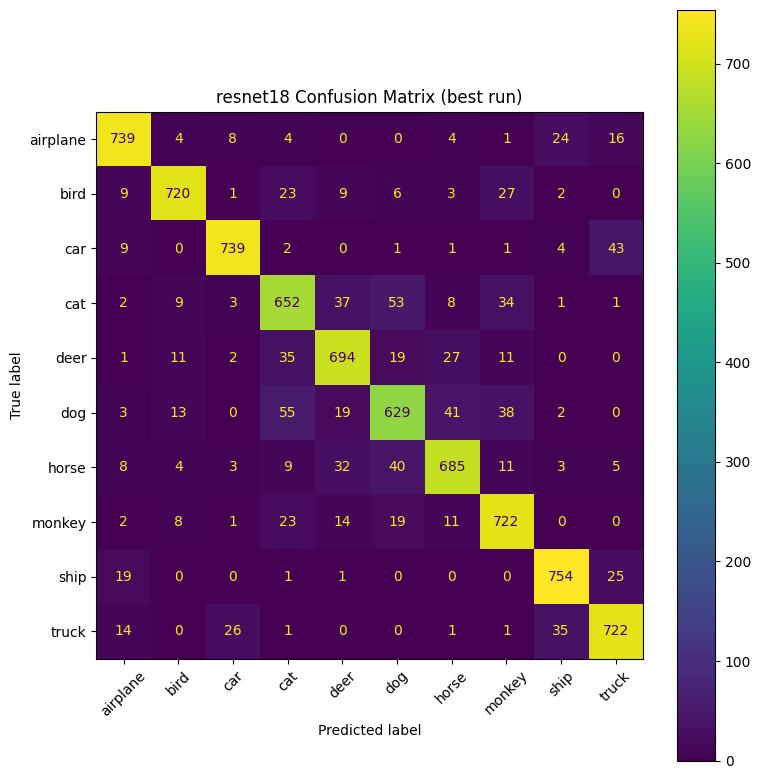

In [ ]:
# More evaluation metrics
# Classification report and confusion matrix for best run in previous cell
# Because our classes are balanced, accuracy is just as good as f1 score. You can confirm this by seeing how similar they are.

def summarize_reports(reports, label_names):
  metrics = ["precision", "recall", "f1-score"]
  summary = {}

  for label in label_names:
    summary[label] = {}
    for m in metrics:
      vals = [rep[label][m] for rep in reports]
      summary[label][m] = (np.mean(vals), np.std(vals))
    summary[label]["support"] = reports[0][label]["support"]

  avg_key = "macro avg"
  summary["average"] = {}
  for m in metrics:
    vals = [rep[avg_key][m] for rep in reports]
    summary["average"][m] = (np.mean(vals), np.std(vals))
  summary["average"]["support"] = reports[0][avg_key]["support"]

  acc_vals = [rep["accuracy"] for rep in reports]
  summary["accuracy"] = (np.mean(acc_vals), np.std(acc_vals))

  return summary

def print_summary_and_confusion(model_name, results):
  test_accs = results["test_accuracies"]
  test_losses = results["test_losses"]
  reports = results["reports"]
  conf_mats = results["conf_mats"]

  print(f"{model_name} test performance over {len(test_accs)} runs: ")
  print(f"Test Accuracy: {test_accs.mean()*100:.2f}% ± {test_accs.std()*100:.2f}%")
  print(f"Test Loss: {test_losses.mean():.4f} ± {test_losses.std():.4f}")

  summary = summarize_reports(reports, classes)

  print(f"\nClassification report (mean ± std over {len(test_accs)} runs):\n")
  header = f"{'Class':<19} {'Precision':<18} {'Recall':<16} {'F1-score':<17} {'Support':<15}"
  print(header)
  print("-" * len(header))

  for label in classes:
    p_mean, p_std = summary[label]["precision"]
    r_mean, r_std = summary[label]["recall"]
    f_mean, f_std = summary[label]["f1-score"]
    support = summary[label]["support"]
    print(f"{label:<15} {p_mean:>7.4f} ± {p_std:<7.4f} {r_mean:>7.4f} ± {r_std:<7.4f} {f_mean:>7.4f} ± {f_std:<7.4f} {support:>10}")

  p_mean, p_std = summary["average"]["precision"]
  r_mean, r_std = summary["average"]["recall"]
  f_mean, f_std = summary["average"]["f1-score"]
  support = summary["average"]["support"]
  print(f"\n{'average':<15} {p_mean:>7.4f} ± {p_std:<7.4f} {r_mean:>7.4f} ± {r_std:<7.4f} {f_mean:>7.4f} ± {f_std:<7.4f} {support:>10}")

  acc_mean, acc_std = summary["accuracy"]
  print(f"\nOverall accuracy: {acc_mean*100:.2f}% ± {acc_std*100:.2f}%")

  best_idx = np.argmax(test_accs)
  best_cm = conf_mats[best_idx]

  fig, ax = plt.subplots(figsize=(8, 8))
  disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=classes)
  disp.plot(ax=ax, xticks_rotation=45)
  plt.title(f"{model_name} Confusion Matrix (best run)")
  plt.tight_layout()
  plt.show()

# Basic CNN results
print_summary_and_confusion("Basic CNN", cnn_results)

# Resnet18 results
print_summary_and_confusion("resnet18", resnet_results)
